# <span style="color:red"> **LSN - Esercitazione 12**
### <span style="color:green"> 05.06.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

### <span style="color:blue">**_Keras - Reti Neurali Profonde e Reti Neurali Convoluzionali per il riconoscimento di immagini_**

In questa esercitazione, sono stati implementati modelli di reti neurali profonde (DNN) utilizzando il pacchetto Keras in Python per affrontare un problema di classificazione multiclasse, ovvero il riconoscimento delle 10 cifre scritte a mano (da 0 a 9) presenti nel dataset MNIST. Questo dataset è composto da $70.000$ immagini in scala di grigio, ognuna rappresentata come una matrice $28\times28$ pixel con valori discreti compresi tra $0$ e $255$, dove ogni pixel indica l’intensità luminosa.  L’allenamento della rete ha dimostrato come le DNN, e in particolare le CNN (reti neurali convoluzionali), siano particolarmente efficaci nell’estrarre features rilevanti da dati strutturati spazialmente, come le immagini, anche in assenza di un modello teorico predefinito su cui effettuare un fit. Questa applicazione sottolinea la versatilità delle reti neurali, che possono essere adattate sia a problemi di approssimazione funzionale (regressione) sia a task complessi di classificazione.

In [40]:
#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True' #This is needed in my Anaconda+MacOsX installation; leave it commented.
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

Per ottenere gli stessi risultati a ogni esecuzione, è necessario imporre il seed, altrimenti sarebbe sempre diverso.

Innanzitutto, si è effettuato il download del dataset MNIST, che è già diviso in sottoinsiemi di training e di test. Poi, si è formattato il dataset per poterlo utilizzare con la DNN, la quale non prende immagini linearizzate, ma matrici. 

In [41]:
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

# reshape data, it could depend on Keras backend
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
# cast to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# rescale data in interval [0,1]
X_train /= 255
X_test /= 255

# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

## <span style="color:blue">**Esercizio 12.1**

Per costruire la rete neurale profonda (DNN) è stata utilizzata la classe `Sequential()` di Keras, che consente di organizzare i layer in una struttura sequenziale lineare attraverso il metodo `add()`. Per questa specifica implementazione, sono stati impiegati esclusivamente layer `Dense`, ciascuno configurato con un numero definito di neuroni (specificato come primo argomento) e una funzione di attivazione appropriata. Per evitare problemi legati a gradienti nulli o saturazione, tipici di funzioni come sigmoide o tanh, è stata preferita la funzione `ReLU` (Rectified Linear Unit), definita come $max⁡(0,z)$, che garantisce una propagazione efficiente del gradiente grazie alla sua natura non saturante. La corretta configurazione dimensionale tra input e output di ogni layer è assicurata specificando la forma dell'input nel primo strato tramite l'argomento `input_shape=(N_features,)`, permettendo a Keras di inferire automaticamente le dimensioni degli strati successivi. Il layer di output, infine, è stato dotato di un'attivazione `softmax`, ideale per problemi di classificazione multiclasse come quello affrontato, in quanto normalizza i valori di uscita in probabilità mutuamente esclusive.

Successivamente, si seleziona la funzione di perdita (loss function) per l'addestramento della DNN. Per problemi di classificazione, la scelta ricade sull'entropia incrociata (cross entropy); poiché i dati di output sono stati convertiti in forma categorica, si è utilizzata la `categorical_crossentropy` disponibile nel modulo losses di Keras. Questa metrica è particolarmente adatta per modelli con output multiclasse in quanto misura la divergenza tra distribuzioni di probabilità reali e predette, penalizzando maggiormente le previsioni errate con alta confidenza e guidando così efficacemente il processo di ottimizzazione durante il training.

Per regolare l'aggiornamento dei pesi durante il training, minimizzando la loss, si utiliza un ottimizzatore. Si è scelto di testare i seguenti ottimizzatori: `sgd` (stochastic gradient descent), , `Adadelta` e `Adamax`. Per testare la performance del modello, è utile osservare l'andamento di una metrica: nel caso di un problema di classificazione, si può guardare l'`accuracy`, che è definita come la percentuale di dati correttamente classificati. 

Dopo aver realizzato la rete, si effetta un training del modello per un certo numero di epoche: ciascuna epoca corrisponde a usare tutti i dati di training suddivisi in minibatches. L'aggiunta di shuffling ai dati di training migliora la stabilità del modello. Per farlo, si utilizza il metodo `fit()` della classe `Sequential`, che richiede obbligatoriamente come argomenti i dati di training di input e di ouput. Inoltre, si può specificare la dimensione dei mini-batch, il numero di epoche di training e i dati di test. Si è scelto di utilizzare $30$ epoche: più si ripete l'operazione di ottimizzare i parametri, più si migliora il risultato; tuttavia, quando si raggiunge il minimo della loss, si ha raggiunto la massima generalizzazione che il modello possa fare, e se si procede oltre si fa overfitting, ovvero si dà credsito all'adattamento ai dati visti, e si ottengono performance peggiori per dati mai visti. 


Training con ottimizzatore: SGD

Risultati con SGD:
- Loss: 0.0672
- Accuracy: 0.9793
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


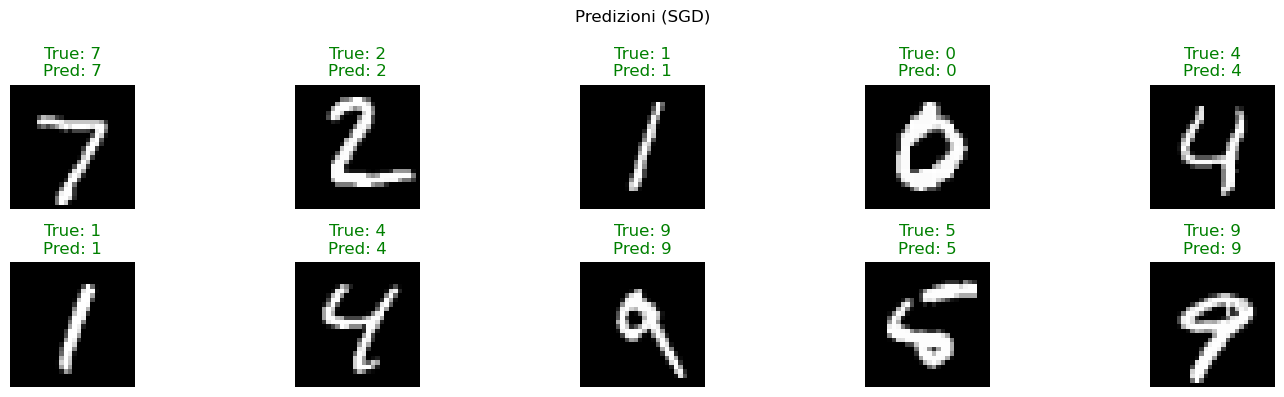


Training con ottimizzatore: Adadelta

Risultati con Adadelta:
- Loss: 0.4387
- Accuracy: 0.8929
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


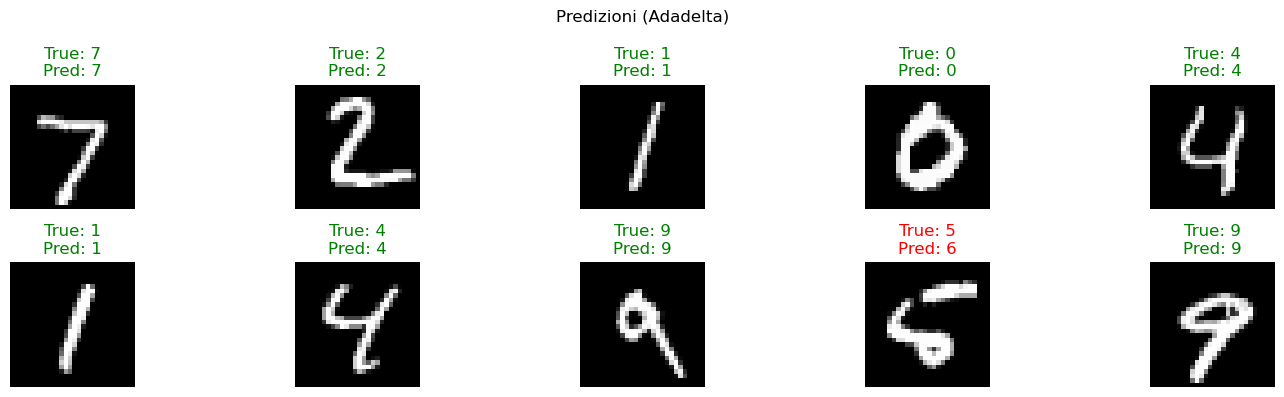


Training con ottimizzatore: Adamax

Risultati con Adamax:
- Loss: 0.0681
- Accuracy: 0.9826
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


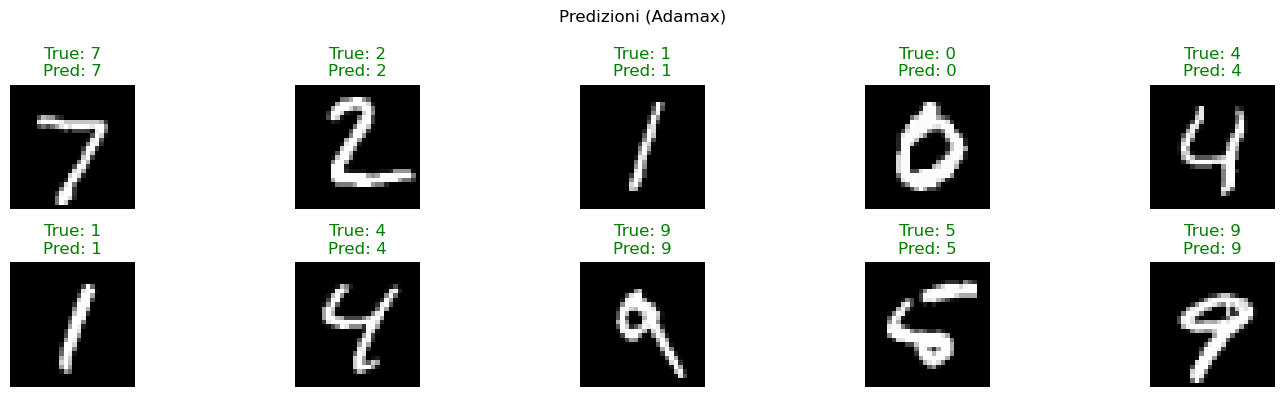

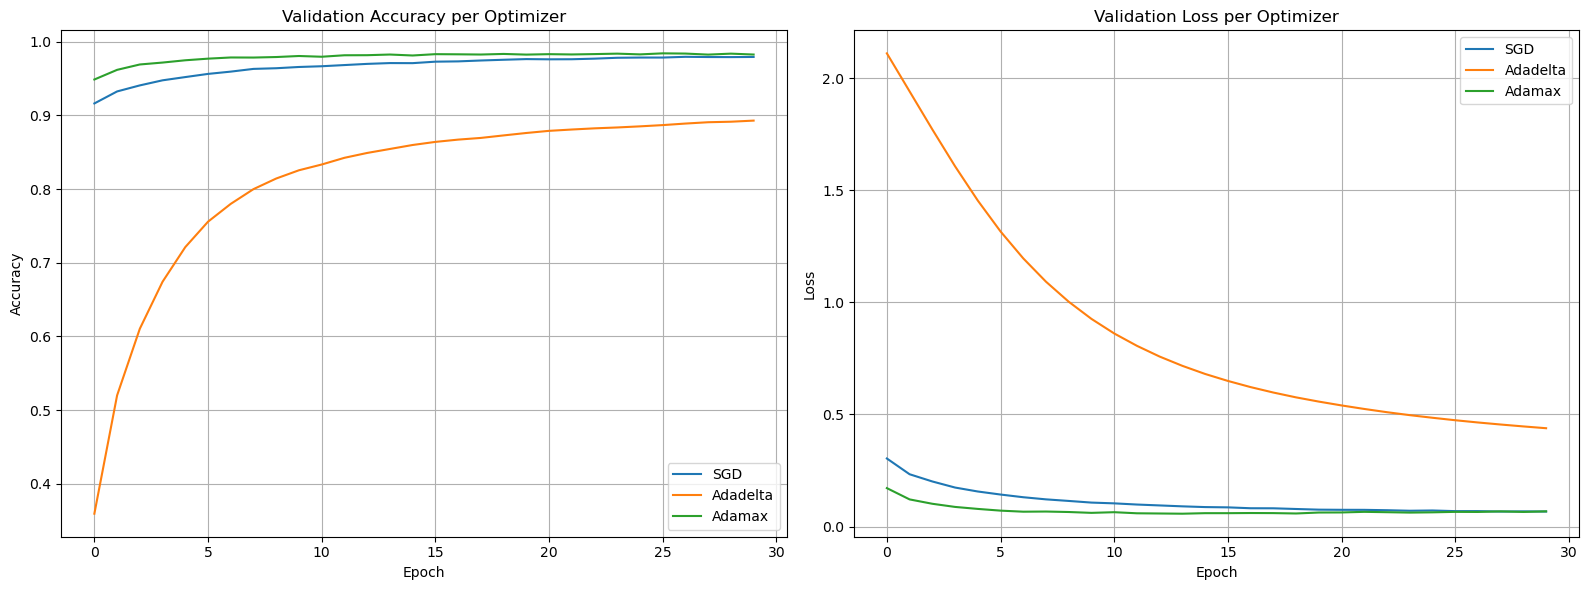

In [42]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import SGD, Adadelta, Adamax
import matplotlib.pyplot as plt
import keras
import numpy as np

def create_DNN():
    model = Sequential()
    model.add(Dense(400, input_shape=(img_rows*img_cols,), activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model

# Lista degli ottimizzatori da testare
optimizers = [
    ('SGD', SGD()),
    ('Adadelta', Adadelta()),
    ('Adamax', Adamax())
]

# Parametri di training
batch_size = 32
epochs = 30

# Dizionario per salvare le storie
histories = {}

for opt_name, optimizer in optimizers:
    print(f"\n{'='*60}")
    print(f"Training con ottimizzatore: {opt_name}")
    print(f"{'='*60}")
    
    # Creazione e compilazione modello
    model = create_DNN()
    model.compile(loss='categorical_crossentropy',
                 optimizer=optimizer,
                 metrics=['accuracy'])
    
    # Addestramento
    history = model.fit(X_train, Y_train,
                       batch_size=batch_size,
                       epochs=epochs,
                       shuffle=True,
                       verbose=0,
                       validation_data=(X_test, Y_test))
    
    # Salvataggio storia
    histories[opt_name] = history
    
    # Valutazione
    score = model.evaluate(X_test, Y_test, verbose=0)
    print(f"\nRisultati con {opt_name}:")
    print(f"- Loss: {score[0]:.4f}")
    print(f"- Accuracy: {score[1]:.4f}")
    
    # Predizioni su X_test
    predictions = model.predict(X_test)
    
    # Visualizzazione prime 10 immagini con predizione
    X_test_vis = X_test.reshape(X_test.shape[0], img_rows, img_cols)

    plt.figure(figsize=(15, 4))
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(X_test_vis[i], cmap='gray')
        true_label = np.argmax(Y_test[i])
        predicted_label = np.argmax(predictions[i])
        color = 'green' if true_label == predicted_label else 'red'
        plt.title(f'True: {true_label}\nPred: {predicted_label}', color=color)
        plt.axis('off')
    plt.suptitle(f'Predizioni ({opt_name})')
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(16, 6))  # (larghezza, altezza) in pollici

# Grafico accuracy
plt.subplot(1, 2, 1)
for opt_name in histories:
    plt.plot(histories[opt_name].history['val_accuracy'], label=opt_name)
plt.title('Validation Accuracy per Optimizer')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid(True)
plt.legend()

# Grafico loss
plt.subplot(1, 2, 2)
for opt_name in histories:
    plt.plot(histories[opt_name].history['val_loss'], label=opt_name)
plt.grid(True)
plt.title('Validation Loss per Optimizer')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


Si osserva che il miglior ottimizzatore è `Adamax`, poiché produce valori di loss inferiori e di accuracy maggiori.

## <span style="color:blue">**Esercizio 12.2**

Si è affrontato il medesimo problema facendo uso di una rete neurale costituita da layer convoluzionali. Una Convolutional Neural Network (CNN) risulta paticolarmente utile per il riconoscimento di cifre scritte a mano innanzitutto perché preserva la topologia dell'immagine attraverso operazioni convoluzionali, catturando pattern locali come linee, curve e bordi. In più, il pooling riduce la sensibilità a piccole traslazioni/rotazioni delle cifre, e questo è utile vista la variabilità nella scrittura a mano (es. cifre spostate o leggermente inclinate). Infine, una DNN presenta maggiore efficienza computazionale: la condivisione dei pesi nei filtri convoluzionali riduce i parametri rispetto a una DNN fully connected.

In [43]:
from keras.layers import Flatten, Conv2D, MaxPooling2D

# reshape data, depending on Keras backend
if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

60000 train samples
10000 test samples


Si è realizzata una rete convoluzionale con le seguenti operazioni: \
- `Conv2D`: applica filtri convoluzionali di dimensione 5x5 all’immagine in input. Lo stride è 1, cioè i filtri scorrono un pixel alla volta. L’attivazione `ReLU` (Rectified Linear Unit) introduce non linearità, azzerando i valori negativi. Serve a estrarre caratteristiche locali (come bordi e texture) dall’immagine.
- `MaxPoolin`: divide ogni feature map in piccole finestre. In ciascuna finestra, prende il valore massimo. Riduce così le dimensioni spaziali (altezza e larghezza) mantenendo solo le informazioni più rilevanti. Aiuta, dunque, a controllare l'overfitting.
- `Dropout`: "spegne" casualmente (cioè imposta a zero) una certa percentuale di neuroni in un layer. Questo viene fatto a ogni batch e in modo diverso ogni volta. Durante l’inferenza (valutazione/test), invece, tutti i neuroni vengono usati normalmente, ma i pesi vengono scalati per compensare.
- `Flatten`: è necessario prima di passare da layer convoluzionali a layer densi (fully connected). Infatti i layer convoluzionali e di pooling producono feature map 2D/3D (con dimensioni: altezza × larghezza × profondità), mentre layer densi richiedono in input vettori 1D.

In [44]:
def create_CNN():
    # instantiate model
    model = Sequential()
    # add first convolutional layer with 10 filters (dimensionality of output space)
    model.add(Conv2D(6, kernel_size=(5, 5), strides=1,activation='relu',input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2,2), strides=2))
    model.add(Conv2D(16, kernel_size=(5, 5), strides=1,activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2), strides=2))
    model.add(Flatten())
    model.add(Dense(128,activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer='Adamax',
                  metrics=['acc'])
    return model

In [45]:
# training parameters
batch_size = 32
epochs = 30

# create the deep conv net
model_CNN=create_CNN()

# train CNN
history_CNN = model_CNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True, # per riorganizzare dati in modo randomico a ogni epoca
          verbose=1,
          validation_data=(X_test, Y_test))

# evaliate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.7328 - loss: 0.8493 - val_acc: 0.9564 - val_loss: 0.1366
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9391 - loss: 0.2084 - val_acc: 0.9687 - val_loss: 0.0914
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9531 - loss: 0.1587 - val_acc: 0.9757 - val_loss: 0.0719
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - acc: 0.9621 - loss: 0.1297 - val_acc: 0.9778 - val_loss: 0.0642
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - acc: 0.9670 - loss: 0.1154 - val_acc: 0.9805 - val_loss: 0.0551
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9704 - loss: 0.1020 - val_acc: 0.9835 - val_loss: 0.0481
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - acc: 0.9726 - loss: 0.0940 - val_acc: 0.9838 - val_loss: 0.0467
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9749 - loss: 0.0831 - val_acc: 0.9851 - val_loss: 0.0432
Epoch 9/30
1875/1875 ━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9862 - loss: 0.0387

Test loss: 0.030818499624729156
Test accuracy: 0.9897000193595886


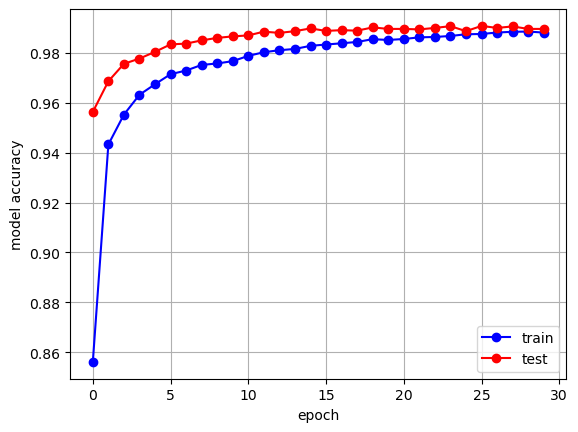

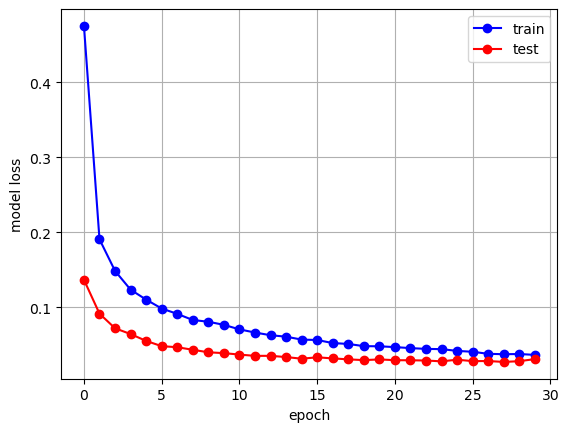

In [46]:
# evaluate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history

# summarize history for accuracy
plt.plot(history_CNN.history['acc'], 'bo-')
plt.plot(history_CNN.history['val_acc'], 'ro-')
plt.ylabel('model accuracy')
plt.xlabel('epoch')
plt.grid(True)
plt.legend(['train', 'test'], loc='best')
plt.show()

# summarize history for loss
plt.plot(history_CNN.history['loss'], 'bo-')
plt.plot(history_CNN.history['val_loss'], 'ro-')
plt.ylabel('model loss')
plt.xlabel('epoch')
plt.grid(True)
plt.legend(['train', 'test'], loc='best')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


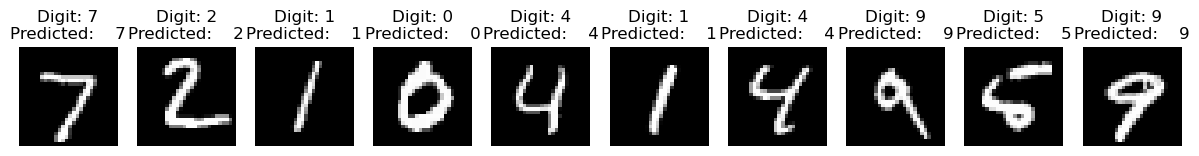

In [47]:
#X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
predictions = model_CNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

## <span style="color:blue">**Esercizio 12.3**

Si è testato il funzionamento della DNN e della CNN precedentemente realizzate per il riconoscimento di cifre scritte manualmente, realizzate tramite `gimp`.

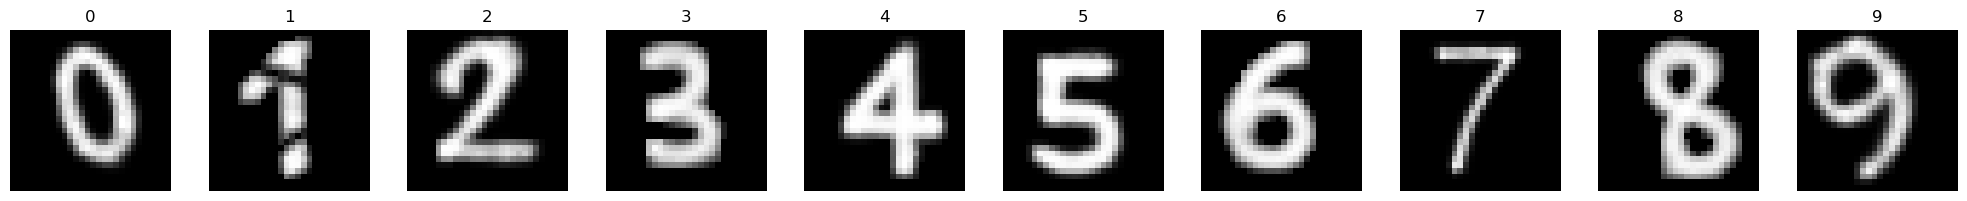

In [48]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

digit_images = []

# Carica le 10 immagini
for n in range(10):
    digit_filename = f"numero{n}.png"
    digit_in = Image.open(digit_filename).convert('L')
    ydim, xdim = digit_in.size
    pix = digit_in.load()
    data = np.zeros((xdim, ydim))
    for j in range(ydim):
        for i in range(xdim):
            data[i, j] = pix[j, i]
    data /= 255
    digit_images.append(data)

# Visualizza tutte le immagini in una sola riga
plt.figure(figsize=(20, 2))  # aumenta larghezza, altezza più bassa
for i in range(10):
    plt.subplot(1, 10, i + 1)  # 1 riga, 10 colonne
    plt.imshow(digit_images[i], cmap='gray')
    plt.axis('off')  # rimuove assi
    plt.title(f"{i}", fontsize=12)

plt.tight_layout()
plt.show()


Test della DNN:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


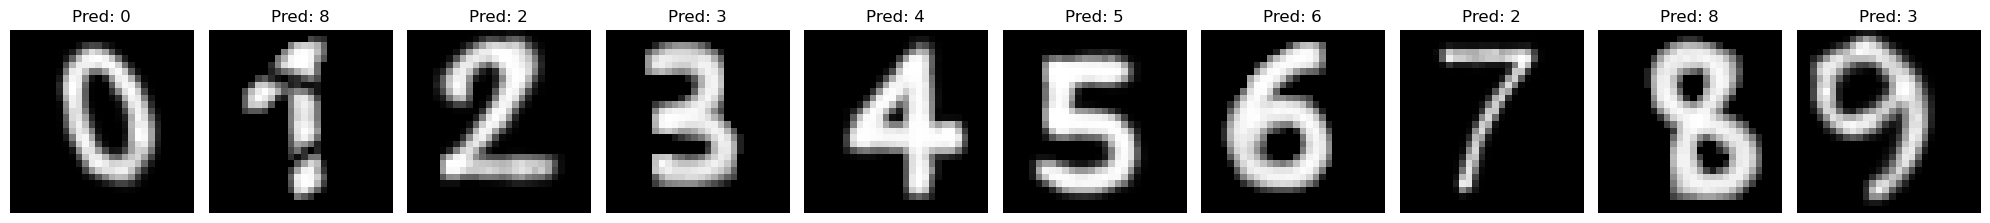

In [49]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

digit_images = []
image_vectors = []

# Carica e processa le immagini
for n in range(10):
    digit_filename = f"numero{n}.png"
    digit_in = Image.open(digit_filename).convert('L')
    ydim, xdim = digit_in.size
    pix = digit_in.load()
    
    # Crea immagine normalizzata
    data = np.zeros((xdim, ydim))
    for j in range(ydim):
        for i in range(xdim):
            data[i, j] = pix[j, i]
    data /= 255
    
    digit_images.append(data)                      # per visualizzazione
    image_vectors.append(data.reshape(-1))         # vettore 1D per DNN

# Convertili in array NumPy per batch prediction
X = np.array(image_vectors)  # shape: (10, xdim * ydim)

# Fai predizioni
predictions = model.predict(X)
predicted_digits = np.argmax(predictions, axis=1)

# Visualizza immagini con predizione
plt.figure(figsize=(20, 2.5))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(digit_images[i], cmap='gray')
    plt.title(f"Pred: {predicted_digits[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


Test della CNN:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


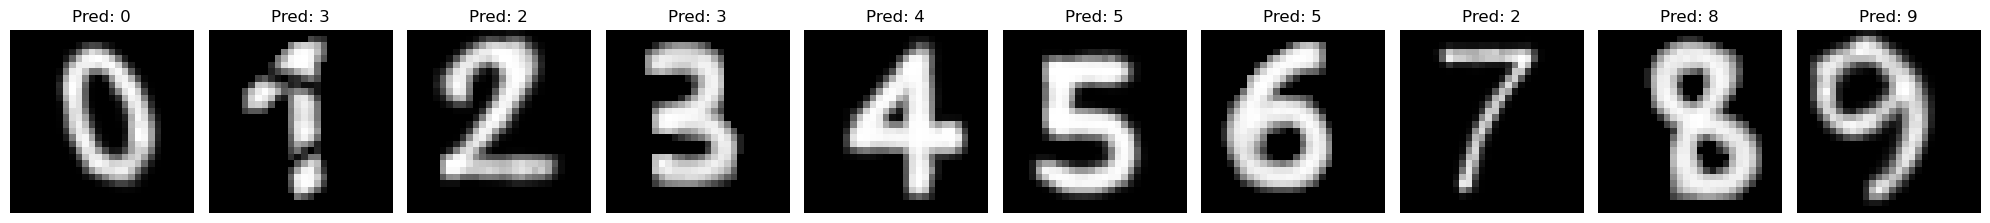

In [50]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

digit_images = []
cnn_input_images = []

# Carica e processa le immagini
for n in range(10):
    digit_filename = f"numero{n}.png"
    digit_in = Image.open(digit_filename).convert('L')
    ydim, xdim = digit_in.size  # NB: PIL restituisce (width, height)
    pix = digit_in.load()
    
    # Crea immagine normalizzata
    data = np.zeros((xdim, ydim))
    for j in range(ydim):
        for i in range(xdim):
            data[i, j] = pix[j, i]
    data /= 255
    
    digit_images.append(data)  # per visualizzazione
    
    # Aggiungi canale (grayscale → 1 canale)
    data_cnn = data.reshape(xdim, ydim, 1)
    cnn_input_images.append(data_cnn)

# Convertili in array NumPy per batch prediction
X = np.array(cnn_input_images)  # shape: (10, xdim, ydim, 1)

# Predizione con la CNN
predictions = model_CNN.predict(X)
predicted_digits = np.argmax(predictions, axis=1)

# Visualizza immagini con predizione
plt.figure(figsize=(20, 2.5))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(digit_images[i], cmap='gray')
    plt.title(f"Pred: {predicted_digits[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


Si osserva che la rete convoluzionale è più abile a riconoscere le cifre, anche qualora - come nel caso dell'1 - abbiano dei difetti. Tuttavia, ha ancora difficoltà a riconoscere le cifre non perfettamente centrate, o troppo sottili.